# CHA Mapping - Statistical Analysis

Welcome! This notebook analyzes your journey data from the CHA Mapping application.

## 📊 What You'll Get:
- **Travel Statistics**: Distance analysis and outlier detection
- **Perception Analysis**: How overall well-being relates to activities and time spent

## 🚀 How to Use:
1. Upload your CSV file when prompted
2. Run all cells (Runtime → Run all)
3. View the generated statistics and visualizations

---

In [26]:
# Install required packages (only needed in Google Colab)
import sys

if 'google.colab' in sys.modules:
    print("📦 Installing required packages...")
    !pip install pandas numpy scipy matplotlib seaborn -q
    print("✅ Packages installed successfully!")
else:
    print("Running locally - ensure packages are installed: pandas, numpy, scipy, matplotlib, seaborn")

Running locally - ensure packages are installed: pandas, numpy, scipy, matplotlib, seaborn


In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📁 Upload Your Data

In [28]:
# File upload (works in Google Colab)
import sys

if 'google.colab' in sys.modules:
    from google.colab import files
    print("📤 Please upload your CSV file:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    print(f"✅ File '{filename}' uploaded successfully!")
else:
    # For local use, specify your file path here
    filename = input("Enter the path to your CSV file: ")

# Load the data
df = pd.read_csv(filename)
print(f"\n📊 Loaded {len(df)} activities from the dataset.")
print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")


📊 Loaded 5 activities from the dataset.
📅 Date range: 2026-01-11 to 2026-01-13


## 🛠️ Data Processing

In [29]:
def parse_coordinates(coord_str):
    """Parse coordinate string like '41.874,-87.658' into (lat, lng) tuple"""
    if pd.isna(coord_str) or coord_str == '':
        return None, None
    try:
        coord_str = str(coord_str).strip('"()').strip()
        parts = coord_str.split(',')
        if len(parts) == 2:
            return float(parts[0]), float(parts[1])
    except:
        pass
    return None, None

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance between two points using Haversine formula (in miles)"""
    if any(pd.isna([lat1, lon1, lat2, lon2])):
        return None
    
    R = 3958.8  # Earth's radius in miles
    
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

def parse_perception_coords(coord_str):
    """Parse perception coordinates from string like '(0.450,0.250)' into (x, y) tuple"""
    if pd.isna(coord_str) or coord_str == '':
        return None, None
    try:
        coord_str = str(coord_str).strip('"()').strip()
        parts = coord_str.split(',')
        if len(parts) == 2:
            return float(parts[0]), float(parts[1])
    except:
        pass
    return None, None

# Parse coordinates
df[['from_lat', 'from_lng']] = df['From Address Coordinates'].apply(
    lambda x: pd.Series(parse_coordinates(x))
)
df[['poi_lat', 'poi_lng']] = df['POI Coordinates'].apply(
    lambda x: pd.Series(parse_coordinates(x))
)
df[['to_lat', 'to_lng']] = df['To Address Coordinates'].apply(
    lambda x: pd.Series(parse_coordinates(x))
)

# Calculate distances
df['distance_from_to_poi_miles'] = df.apply(
    lambda row: haversine_distance(row['from_lat'], row['from_lng'], 
                                   row['poi_lat'], row['poi_lng']), axis=1
)
df['distance_poi_to_to_miles'] = df.apply(
    lambda row: haversine_distance(row['poi_lat'], row['poi_lng'], 
                                   row['to_lat'], row['to_lng']), axis=1
)
df['total_distance_miles'] = df['distance_from_to_poi_miles'].fillna(0) + df['distance_poi_to_to_miles'].fillna(0)

# Parse perception coordinates and calculate overall well-being score
# X-axis = Dissatisfied (-1) ← → Satisfied (+1)
# Y-axis = Stressed (-1) ← → Calm (+1)
df[['perception_x', 'perception_y']] = df['Perception Grid Coordinates'].apply(
    lambda x: pd.Series(parse_perception_coords(x))
)

# Calculate overall well-being score (average of satisfaction and stress)
df['wellbeing_score'] = (df['perception_x'] + df['perception_y']) / 2

print("✅ Data processing complete!")
print(f"📏 Successfully calculated distances for {df['total_distance_miles'].notna().sum()} activities")
print(f"🧠 Found perception data for {df['wellbeing_score'].notna().sum()} activities")

✅ Data processing complete!
📏 Successfully calculated distances for 5 activities
🧠 Found perception data for 5 activities


---
# 📍 SECTION 1: TRAVEL STATISTICS
---

## 1.1 Overall Travel Summary

In [30]:
# Overall statistics
total_activities = len(df)
total_distance = df['total_distance_miles'].sum()
avg_distance = df['total_distance_miles'].mean()
median_distance = df['total_distance_miles'].median()
min_distance = df['total_distance_miles'].min()
max_distance = df['total_distance_miles'].max()
std_distance = df['total_distance_miles'].std()

print("="*60)
print("🗺️  OVERALL TRAVEL SUMMARY")
print("="*60)
print(f"Total Activities:           {total_activities}")
print(f"Total Distance Traveled:    {total_distance:.2f} miles")
print(f"Average Distance per Trip:  {avg_distance:.2f} miles")
print(f"Median Distance per Trip:   {median_distance:.2f} miles")
print(f"Shortest Trip:              {min_distance:.2f} miles")
print(f"Longest Trip:               {max_distance:.2f} miles")
print(f"Standard Deviation:         {std_distance:.2f} miles")
print("="*60)

🗺️  OVERALL TRAVEL SUMMARY
Total Activities:           5
Total Distance Traveled:    21.29 miles
Average Distance per Trip:  4.26 miles
Median Distance per Trip:   4.63 miles
Shortest Trip:              1.98 miles
Longest Trip:               6.70 miles
Standard Deviation:         1.76 miles


## 1.2 Distance Distribution

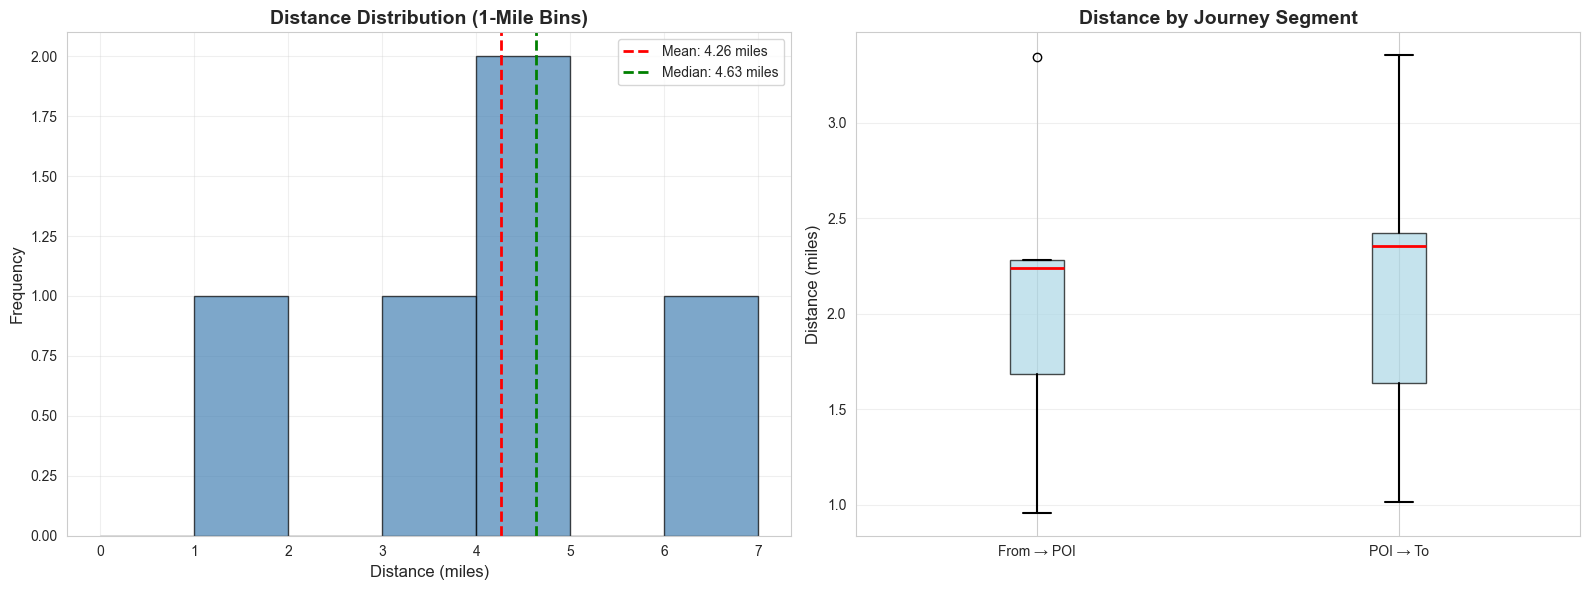

✅ Distance visualizations generated!


In [31]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram with 1-mile bins
max_dist = df['total_distance_miles'].max()
bins = np.arange(0, max_dist + 1, 1)  # 1-mile bins

axes[0].hist(df['total_distance_miles'].dropna(), bins=bins, color='steelblue', 
             edgecolor='black', alpha=0.7)
axes[0].axvline(avg_distance, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {avg_distance:.2f} miles')
axes[0].axvline(median_distance, color='green', linestyle='--', linewidth=2, 
                label=f'Median: {median_distance:.2f} miles')
axes[0].set_xlabel('Distance (miles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distance Distribution (1-Mile Bins)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Box plot
box_data = [df['distance_from_to_poi_miles'].dropna(), 
            df['distance_poi_to_to_miles'].dropna()]
bp = axes[1].boxplot(box_data, labels=['From → POI', 'POI → To'], 
                     patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
axes[1].set_ylabel('Distance (miles)', fontsize=12)
axes[1].set_title('Distance by Journey Segment', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Distance visualizations generated!")

## 1.3 Outlier Detection

🔍 OUTLIER DETECTION
Total Outliers Detected:     1 (20.0%)
Unusually Long Journeys:     1
Unusually Short Journeys:    0

Outlier Threshold:           > 6.66 miles or < 1.32 miles

🚗 LONGEST JOURNEYS:
------------------------------------------------------------
2026-01-11 | Other                |   6.70 miles | Drove Myself


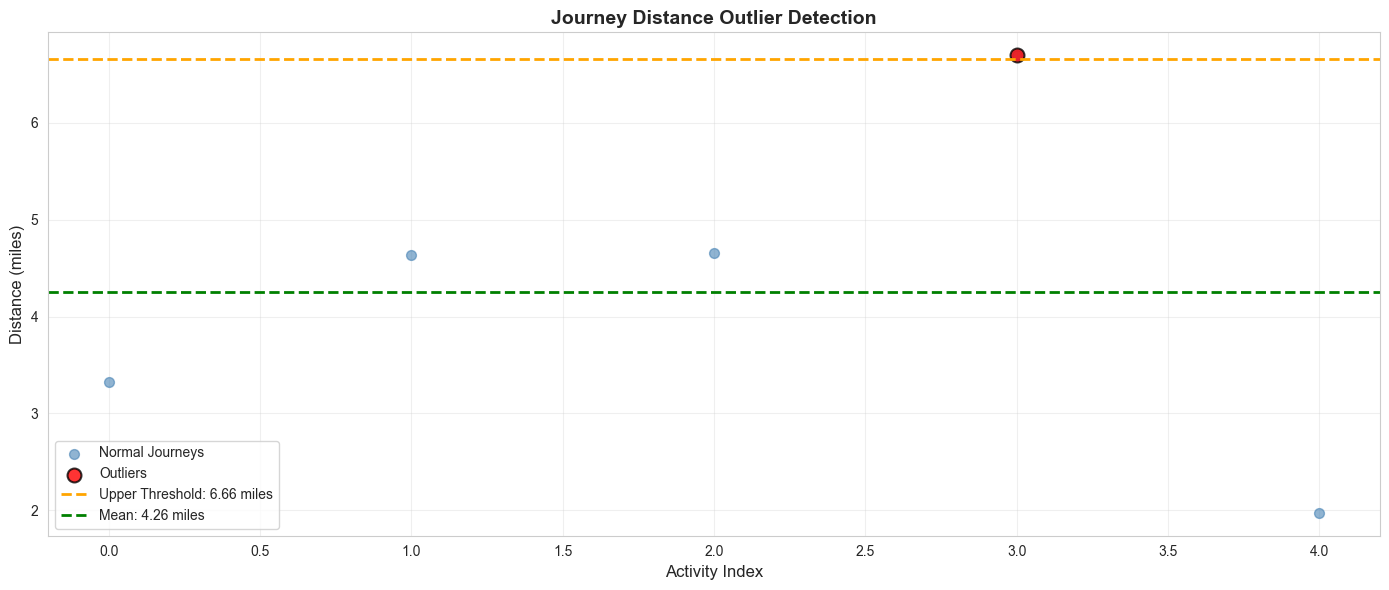

In [32]:
# Detect outliers using IQR method
Q1 = df['total_distance_miles'].quantile(0.25)
Q3 = df['total_distance_miles'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['total_distance_miles'] < lower_bound) | (df['total_distance_miles'] > upper_bound)]
long_outliers = outliers[outliers['total_distance_miles'] > upper_bound]
short_outliers = outliers[outliers['total_distance_miles'] < lower_bound]

print("="*60)
print("🔍 OUTLIER DETECTION")
print("="*60)
print(f"Total Outliers Detected:     {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Unusually Long Journeys:     {len(long_outliers)}")
print(f"Unusually Short Journeys:    {len(short_outliers)}")
print(f"\nOutlier Threshold:           > {upper_bound:.2f} miles or < {lower_bound:.2f} miles")
print("="*60)

if len(long_outliers) > 0:
    print("\n🚗 LONGEST JOURNEYS:")
    print("-" * 60)
    top_long = long_outliers.nlargest(min(5, len(long_outliers)), 'total_distance_miles')[[
        'Date', 'Activity Type', 'Place Name', 'total_distance_miles', 'Transportation'
    ]]
    for idx, row in top_long.iterrows():
        print(f"{row['Date']} | {row['Activity Type']:20s} | {row['total_distance_miles']:6.2f} miles | {row['Transportation']}")

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(range(len(df)), df['total_distance_miles'], alpha=0.6, s=50, 
           label='Normal Journeys', color='steelblue')
if len(outliers) > 0:
    ax.scatter(outliers.index, outliers['total_distance_miles'], color='red', s=100, 
               alpha=0.8, label='Outliers', edgecolors='black', linewidths=1.5)
ax.axhline(upper_bound, color='orange', linestyle='--', linewidth=2, 
           label=f'Upper Threshold: {upper_bound:.2f} miles')
ax.axhline(avg_distance, color='green', linestyle='--', linewidth=2, 
           label=f'Mean: {avg_distance:.2f} miles')
ax.set_xlabel('Activity Index', fontsize=12)
ax.set_ylabel('Distance (miles)', fontsize=12)
ax.set_title('Journey Distance Outlier Detection', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 🧠 SECTION 2: PERCEPTION ANALYSIS

**Overall Well-Being Score**: Combines satisfaction (X-axis) and stress level (Y-axis) into a single metric.
- Ranges from -1 (dissatisfied & stressed) to +1 (satisfied & calm)

---

## 2.1 Time Spent vs Overall Well-Being

⏱️  TIME SPENT vs OVERALL WELL-BEING
Correlation coefficient: -0.606
P-value: 0.2787
➜ Not statistically significant (p > 0.05)


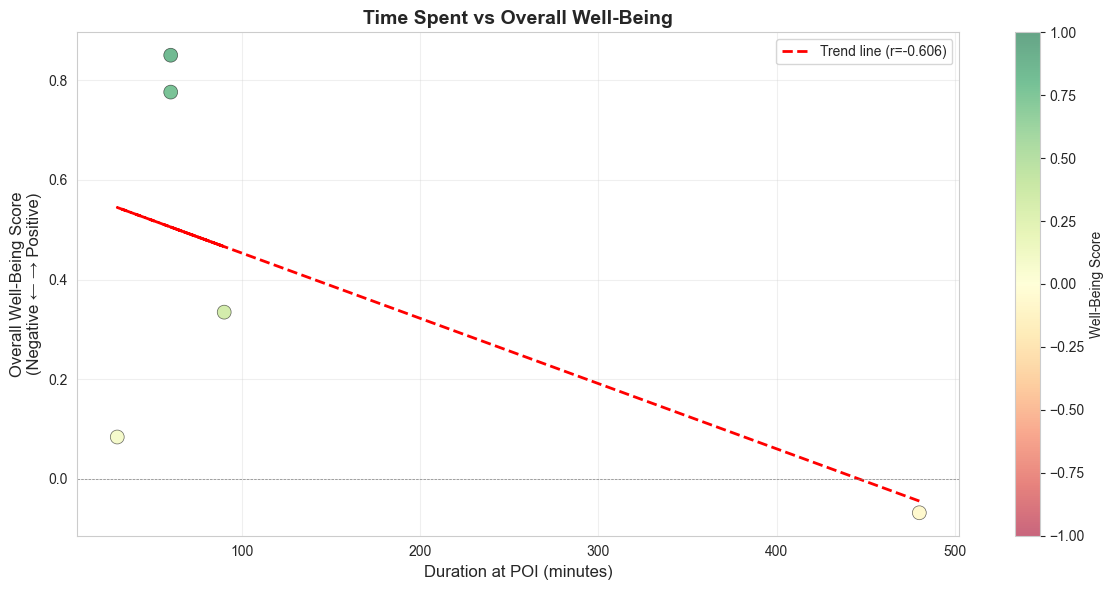

In [33]:
# Filter data with perception values
perception_data = df[df['wellbeing_score'].notna()].copy()

if len(perception_data) > 0:
    from scipy.stats import pearsonr
    valid_data = perception_data[perception_data['Duration at POI (minutes)'].notna()]
    
    if len(valid_data) > 2:
        # Calculate correlation
        corr, p_value = pearsonr(valid_data['Duration at POI (minutes)'], valid_data['wellbeing_score'])
        
        print("="*70)
        print("⏱️  TIME SPENT vs OVERALL WELL-BEING")
        print("="*70)
        print(f"Correlation coefficient: {corr:+.3f}")
        print(f"P-value: {p_value:.4f}")
        if p_value < 0.05:
            if corr > 0.3:
                print("➜ More time spent → Better overall well-being ✓")
            elif corr < -0.3:
                print("➜ More time spent → Worse overall well-being ❌")
            else:
                print("➜ Weak correlation")
        else:
            print("➜ Not statistically significant (p > 0.05)")
        print("="*70)
    
    # Scatter plot
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(perception_data['Duration at POI (minutes)'], 
                         perception_data['wellbeing_score'],
                         alpha=0.6, s=100, c=perception_data['wellbeing_score'], 
                         cmap='RdYlGn', edgecolors='black', linewidths=0.5,
                         vmin=-1, vmax=1)
    
    # Add regression line
    if len(valid_data) > 2:
        z = np.polyfit(valid_data['Duration at POI (minutes)'], valid_data['wellbeing_score'], 1)
        p = np.poly1d(z)
        plt.plot(valid_data['Duration at POI (minutes)'], 
                p(valid_data['Duration at POI (minutes)']), 
                "r--", linewidth=2, label=f'Trend line (r={corr:.3f})')
    
    plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    plt.xlabel('Duration at POI (minutes)', fontsize=12)
    plt.ylabel('Overall Well-Being Score\n(Negative ← → Positive)', fontsize=12)
    plt.title('Time Spent vs Overall Well-Being', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='Well-Being Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No perception data available.")

## 2.2 Activity Type vs Overall Well-Being


🎯 OVERALL WELL-BEING BY ACTIVITY TYPE
Activity Type                   Avg Well-Being      Count
----------------------------------------------------------------------
Wellness                            0.570    😊          3
Other                               0.334    😊          1
Healthcare                         -0.068    😐          1

💡 Scale: -1 (Negative) ← 0 (Neutral) → +1 (Positive)


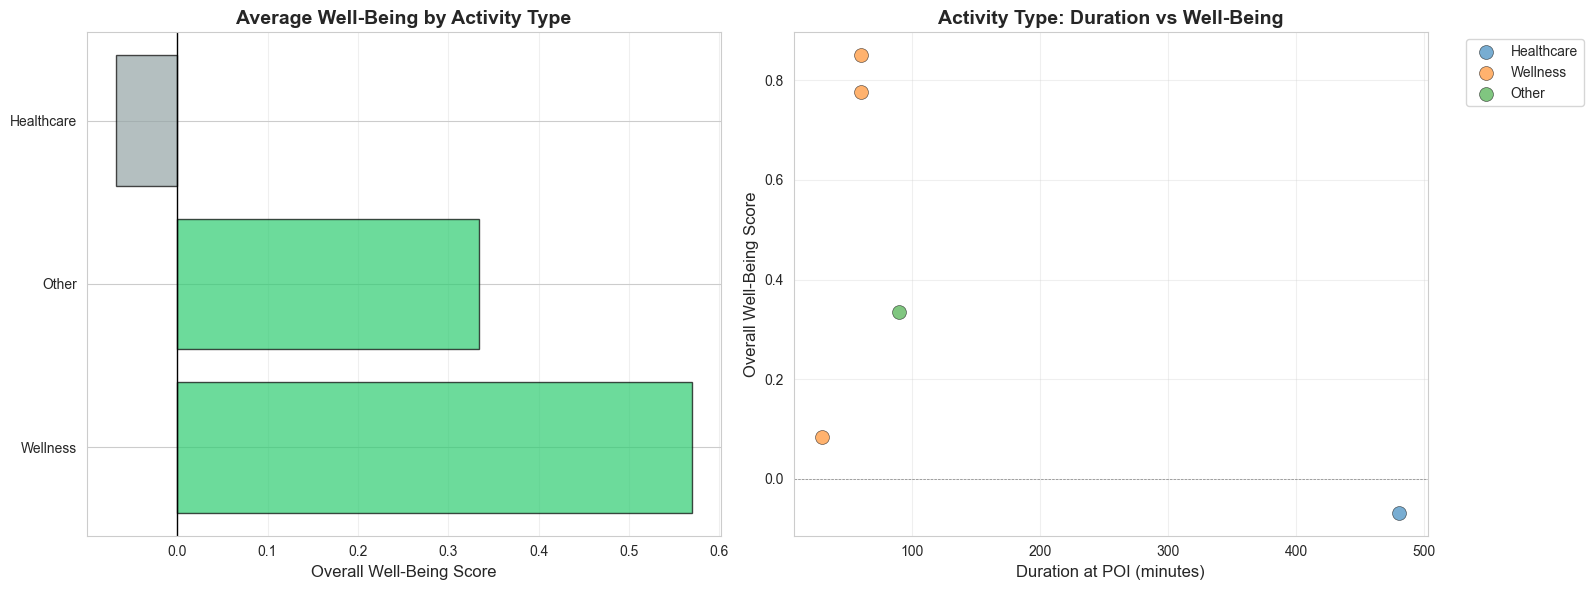

In [34]:
if len(perception_data) > 0:
    # Calculate average well-being by activity type
    activity_perception = perception_data.groupby('Activity Type').agg({
        'wellbeing_score': ['mean', 'count']
    }).round(3)
    activity_perception.columns = ['Avg Well-Being', 'Count']
    activity_perception = activity_perception.sort_values('Avg Well-Being', ascending=False)
    
    print("\n" + "="*70)
    print("🎯 OVERALL WELL-BEING BY ACTIVITY TYPE")
    print("="*70)
    print(f"{'Activity Type':<30} {'Avg Well-Being':>15} {'Count':>10}")
    print("-"*70)
    for activity, row in activity_perception.iterrows():
        emoji = "😊" if row['Avg Well-Being'] > 0.3 else "😐" if row['Avg Well-Being'] > -0.3 else "😟"
        print(f"{activity:<30} {row['Avg Well-Being']:>10.3f} {emoji:>4} {row['Count']:>10.0f}")
    print("="*70)
    print("\n💡 Scale: -1 (Negative) ← 0 (Neutral) → +1 (Positive)")
    
    # Create visualizations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart - Well-being by Activity
    colors = ['#2ecc71' if x > 0.3 else '#e74c3c' if x < -0.3 else '#95a5a6' 
              for x in activity_perception['Avg Well-Being']]
    axes[0].barh(activity_perception.index, activity_perception['Avg Well-Being'], 
                color=colors, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color='black', linewidth=1)
    axes[0].set_xlabel('Overall Well-Being Score', fontsize=12)
    axes[0].set_title('Average Well-Being by Activity Type', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Scatter - Duration vs Well-being by Activity
    for activity in perception_data['Activity Type'].unique():
        mask = perception_data['Activity Type'] == activity
        data = perception_data[mask]
        axes[1].scatter(data['Duration at POI (minutes)'], data['wellbeing_score'],
                       label=activity, alpha=0.6, s=100, edgecolors='black', linewidths=0.5)
    axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
    axes[1].set_xlabel('Duration at POI (minutes)', fontsize=12)
    axes[1].set_ylabel('Overall Well-Being Score', fontsize=12)
    axes[1].set_title('Activity Type: Duration vs Well-Being', fontsize=14, fontweight='bold')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No perception data available.")

## 2.3 Geographic Health Indicators vs Well-Being


🌍 GEOGRAPHIC HEALTH INDICATORS vs WELL-BEING

1. NDI (Neighborhood Deprivation Index):
   Correlation: -0.400, P-value: 0.5043
   ➜ Not statistically significant

2. TES (Tree Equity Score):
   Correlation: -0.232, P-value: 0.7075
   ➜ Not statistically significant

3. MHLTH (Mental Health Prevalence):
   Correlation: -0.369, P-value: 0.5415
   ➜ Not statistically significant


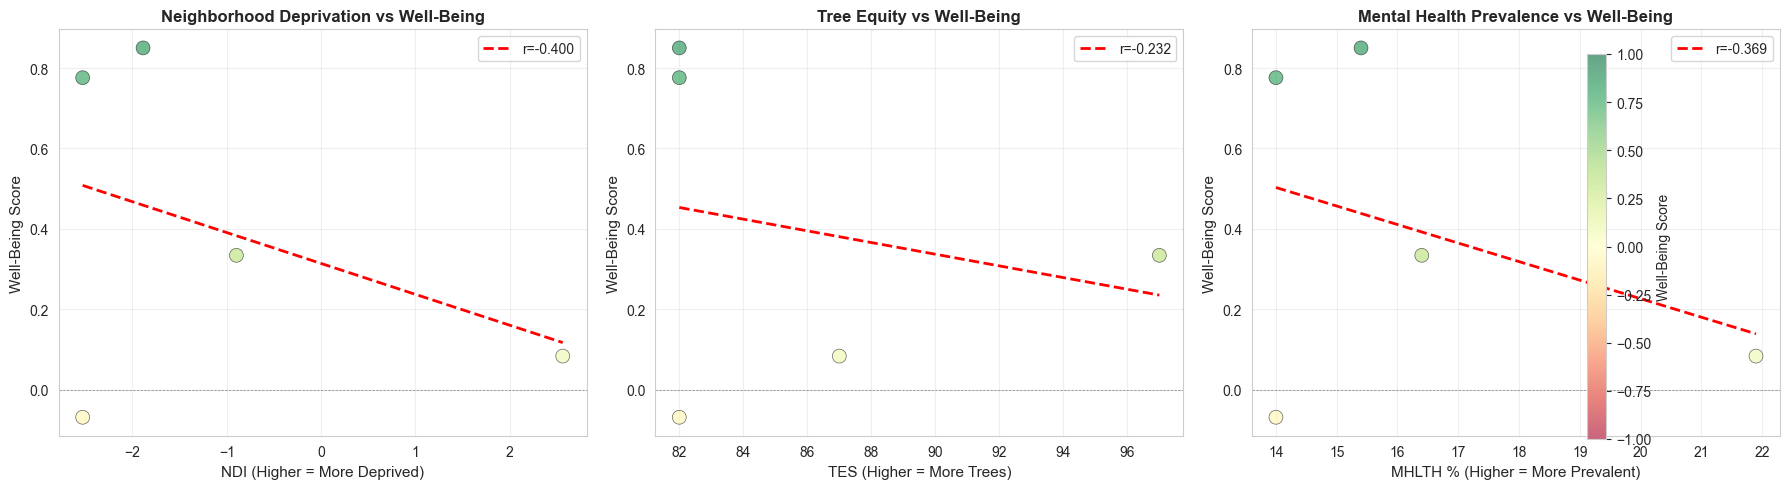


💡 Interpretation Guide:
   • NDI: Measures neighborhood disadvantage (poverty, education, housing, etc.)
   • TES: Measures tree canopy coverage and equity in access to nature
   • MHLTH: Percentage of adults reporting poor mental health days


In [35]:
if len(perception_data) > 0:
    # Filter data with both geodata and wellbeing
    geo_data = perception_data[
        perception_data['NDI (Neighborhood Deprivation Index)'].notna() &
        perception_data['TES (Tree Equity Score)'].notna() &
        perception_data['MHLTH (Mental Health Crude Prevalence)'].notna()
    ].copy()
    
    if len(geo_data) > 2:
        from scipy.stats import pearsonr
        
        # Calculate correlations
        corr_ndi, p_ndi = pearsonr(geo_data['NDI (Neighborhood Deprivation Index)'], geo_data['wellbeing_score'])
        corr_tes, p_tes = pearsonr(geo_data['TES (Tree Equity Score)'], geo_data['wellbeing_score'])
        corr_mhlth, p_mhlth = pearsonr(geo_data['MHLTH (Mental Health Crude Prevalence)'], geo_data['wellbeing_score'])
        
        print("\n" + "="*75)
        print("🌍 GEOGRAPHIC HEALTH INDICATORS vs WELL-BEING")
        print("="*75)
        
        print(f"\n1. NDI (Neighborhood Deprivation Index):")
        print(f"   Correlation: {corr_ndi:+.3f}, P-value: {p_ndi:.4f}")
        if p_ndi < 0.05:
            if corr_ndi < -0.3:
                print(f"   ➜ Higher deprivation → Lower well-being ❌")
            elif corr_ndi > 0.3:
                print(f"   ➜ Higher deprivation → Higher well-being (unexpected)")
            else:
                print(f"   ➜ Weak correlation")
        else:
            print(f"   ➜ Not statistically significant")
        
        print(f"\n2. TES (Tree Equity Score):")
        print(f"   Correlation: {corr_tes:+.3f}, P-value: {p_tes:.4f}")
        if p_tes < 0.05:
            if corr_tes > 0.3:
                print(f"   ➜ More trees → Higher well-being 🌳")
            elif corr_tes < -0.3:
                print(f"   ➜ More trees → Lower well-being (unexpected)")
            else:
                print(f"   ➜ Weak correlation")
        else:
            print(f"   ➜ Not statistically significant")
        
        print(f"\n3. MHLTH (Mental Health Prevalence):")
        print(f"   Correlation: {corr_mhlth:+.3f}, P-value: {p_mhlth:.4f}")
        if p_mhlth < 0.05:
            if corr_mhlth < -0.3:
                print(f"   ➜ Higher MH prevalence → Lower well-being ❌")
            elif corr_mhlth > 0.3:
                print(f"   ➜ Higher MH prevalence → Higher well-being (unexpected)")
            else:
                print(f"   ➜ Weak correlation")
        else:
            print(f"   ➜ Not statistically significant")
        
        print("="*75)
        
        # Create visualizations - 3 scatter plots
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # 1. NDI vs Well-being
        scatter1 = axes[0].scatter(geo_data['NDI (Neighborhood Deprivation Index)'], 
                                   geo_data['wellbeing_score'],
                                   alpha=0.6, s=100, c=geo_data['wellbeing_score'], 
                                   cmap='RdYlGn', edgecolors='black', linewidths=0.5,
                                   vmin=-1, vmax=1)
        z1 = np.polyfit(geo_data['NDI (Neighborhood Deprivation Index)'], geo_data['wellbeing_score'], 1)
        p1 = np.poly1d(z1)
        x_range1 = np.linspace(geo_data['NDI (Neighborhood Deprivation Index)'].min(), 
                               geo_data['NDI (Neighborhood Deprivation Index)'].max(), 100)
        axes[0].plot(x_range1, p1(x_range1), "r--", linewidth=2, label=f'r={corr_ndi:.3f}')
        axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
        axes[0].set_xlabel('NDI (Higher = More Deprived)', fontsize=11)
        axes[0].set_ylabel('Well-Being Score', fontsize=11)
        axes[0].set_title('Neighborhood Deprivation vs Well-Being', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. TES vs Well-being
        scatter2 = axes[1].scatter(geo_data['TES (Tree Equity Score)'], 
                                   geo_data['wellbeing_score'],
                                   alpha=0.6, s=100, c=geo_data['wellbeing_score'], 
                                   cmap='RdYlGn', edgecolors='black', linewidths=0.5,
                                   vmin=-1, vmax=1)
        z2 = np.polyfit(geo_data['TES (Tree Equity Score)'], geo_data['wellbeing_score'], 1)
        p2 = np.poly1d(z2)
        x_range2 = np.linspace(geo_data['TES (Tree Equity Score)'].min(), 
                               geo_data['TES (Tree Equity Score)'].max(), 100)
        axes[1].plot(x_range2, p2(x_range2), "r--", linewidth=2, label=f'r={corr_tes:.3f}')
        axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
        axes[1].set_xlabel('TES (Higher = More Trees)', fontsize=11)
        axes[1].set_ylabel('Well-Being Score', fontsize=11)
        axes[1].set_title('Tree Equity vs Well-Being', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 3. MHLTH vs Well-being
        scatter3 = axes[2].scatter(geo_data['MHLTH (Mental Health Crude Prevalence)'], 
                                   geo_data['wellbeing_score'],
                                   alpha=0.6, s=100, c=geo_data['wellbeing_score'], 
                                   cmap='RdYlGn', edgecolors='black', linewidths=0.5,
                                   vmin=-1, vmax=1)
        z3 = np.polyfit(geo_data['MHLTH (Mental Health Crude Prevalence)'], geo_data['wellbeing_score'], 1)
        p3 = np.poly1d(z3)
        x_range3 = np.linspace(geo_data['MHLTH (Mental Health Crude Prevalence)'].min(), 
                               geo_data['MHLTH (Mental Health Crude Prevalence)'].max(), 100)
        axes[2].plot(x_range3, p3(x_range3), "r--", linewidth=2, label=f'r={corr_mhlth:.3f}')
        axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')
        axes[2].set_xlabel('MHLTH % (Higher = More Prevalent)', fontsize=11)
        axes[2].set_ylabel('Well-Being Score', fontsize=11)
        axes[2].set_title('Mental Health Prevalence vs Well-Being', fontsize=12, fontweight='bold')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        # Add colorbar
        fig.colorbar(scatter2, ax=axes, label='Well-Being Score', fraction=0.02, pad=0.04)
        
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Interpretation Guide:")
        print("   • NDI: Measures neighborhood disadvantage (poverty, education, housing, etc.)")
        print("   • TES: Measures tree canopy coverage and equity in access to nature")
        print("   • MHLTH: Percentage of adults reporting poor mental health days")
    else:
        print("⚠️ Not enough geodata available for correlation analysis.")
else:
    print("⚠️ No perception data available.")

---
# 📋 ANALYSIS COMPLETE
---

In [36]:
print("\n" + "="*60)
print("               ANALYSIS COMPLETE")
print("="*60)
print("\n✅ All statistical analyses have been generated!")
print("\n📊 Summary:")
print(f"   • Analyzed {len(df)} activities")
print(f"   • Distance data: {df['total_distance_miles'].notna().sum()} entries")
print(f"   • Perception data: {df['wellbeing_score'].notna().sum()} entries")
print("\n💡 Key Insights:")
print(f"   • Average trip distance: {avg_distance:.2f} miles")
print(f"   • Total travel distance: {total_distance:.2f} miles")
if len(perception_data) > 0:
    avg_wellbeing = perception_data['wellbeing_score'].mean()
    print(f"   • Average well-being score: {avg_wellbeing:+.3f}")
print("\n" + "="*60)


               ANALYSIS COMPLETE

✅ All statistical analyses have been generated!

📊 Summary:
   • Analyzed 5 activities
   • Distance data: 5 entries
   • Perception data: 5 entries

💡 Key Insights:
   • Average trip distance: 4.26 miles
   • Total travel distance: 21.29 miles
   • Average well-being score: +0.395

